# Tableau - Graph - Bubble
- https://help.tableau.com/current/pro/desktop/en-us/buildexamples_bubbles.htm
- 

## Method 1: 
- The "Show Me" Tab (Fastest)Connect to Data: Open Tableau and choose the Sample - Superstore dataset.
- Select Fields: Hold Ctrl (or Cmd on Mac) and click one Dimension (e.g., Sub-Category) and one Measure (e.g., Sales) in the Data pane.
- Generate Chart: Click the Show Me panel in the top-right corner and select Packed Bubbles.


## Method 2: 
- Drag-and-Drop (Manual)If you prefer building it field-by-field, follow these steps using the Marks card:Open a new worksheet.
- Change the mark type dropdown on the Marks card from Automatic to Circle.
- Drag the Sub-Category dimension onto Detail.Drag the Sales measure onto Size.
- Drag the Sub-Category dimension onto Color to give each bubble its own distinct color.

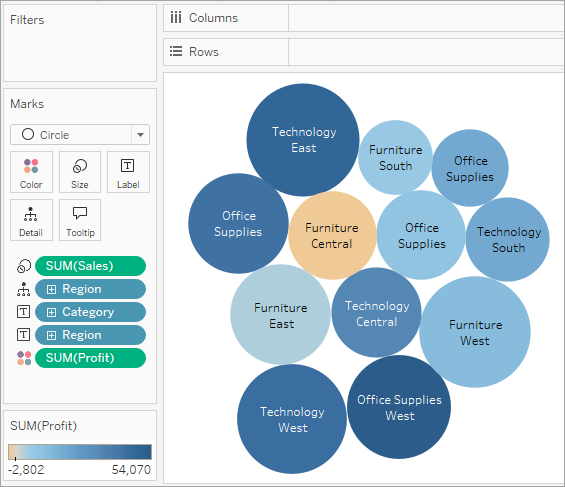

## Python Way


In [11]:
# Data
import numpy as np
import pandas as pd
import datetime as dt
url1 = 'https://raw.githubusercontent.com/dupadhyaya/piit/refs/heads/main/data/superstore_orders.csv'
print(url1)
sales = pd.read_csv(url1)
sales.shape

https://raw.githubusercontent.com/dupadhyaya/piit/refs/heads/main/data/superstore_orders.csv


(10194, 21)

In [12]:
bubble_data = ( sales.groupby(['Category', 'Sub-Category'], as_index=False)\
    .agg(Sales=('Sales', 'sum')))
bubble_data.head()

,Category,Sub-Category,Sales
0,Furniture,Bookcases,115361.2043
1,Furniture,Chairs,335768.2490
2,Furniture,Furnishings,95598.1260
3,Furniture,Tables,208020.1820
4,Office Supplies,Appliances,108213.1850


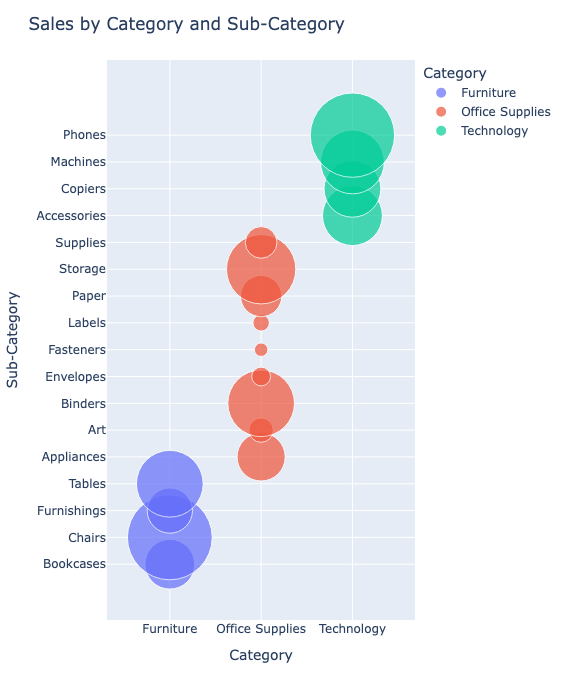

In [13]:
import plotly.express as px

fig = px.scatter(   bubble_data,   x='Category',  y='Sub-Category',  size='Sales',  color='Category',
    hover_name='Sub-Category',    size_max=60)
fig.update_layout( title='Sales by Category and Sub-Category',   height=700)
fig.show();

In [6]:
#!pip install circlify

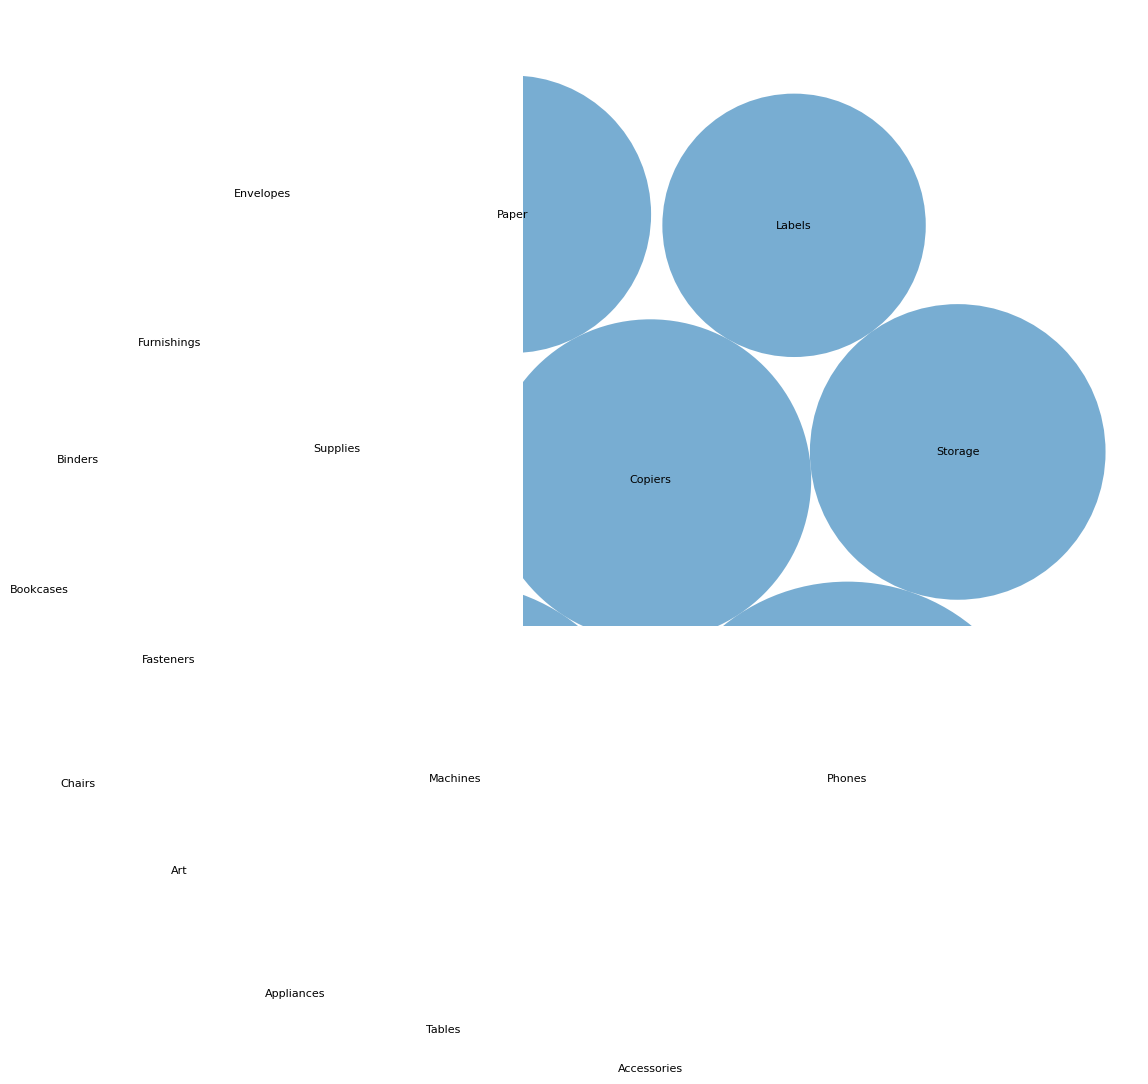

In [10]:
import circlify
import matplotlib.pyplot as plt
data = bubble_data['Sales'].tolist()
circles = circlify.circlify(  data,   show_enclosure=False,   target_enclosure=circlify.Circle(0, 0, 1)
)
fig, ax = plt.subplots(figsize=(8,8))
for circle, label in zip(circles, bubble_data['Sub-Category']):
    x, y, r = circle.x, circle.y, circle.r
    ax.add_patch(plt.Circle((x, y), r, alpha=0.6))
    ax.text(x, y, label, ha='center', va='center', fontsize=8)
ax.set_aspect('equal')
ax.axis('off')
plt.show();

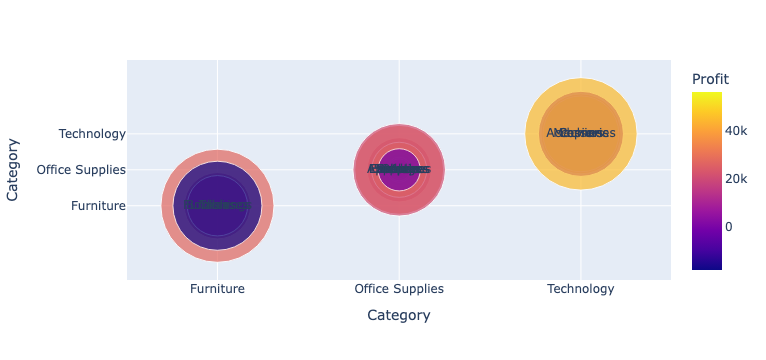

In [9]:
bubble_data = (    sales.groupby(['Category', 'Sub-Category'], as_index=False)
    .agg(        Sales=('Sales', 'sum'),       Profit=('Profit', 'sum')    ))
fig = px.scatter(    bubble_data,    x='Category',    y='Category',    size='Sales',    color='Profit',    hover_name='Sub-Category',
    text='Sub-Category',    size_max=80)
fig.show();